  device_type     brand              model  release_year       os form_factor  \
0     Desktop   Samsung  Samsung Forge Xdi          2022  Windows         Atx   
1      Laptop   Samsung    Samsung Pro Km8          2022  Windows  Mainstream   
2     Desktop    Lenovo   Lenovo Strix Bie          2024    Macos         Sff   
3     Desktop      Dell      Dell Cube Axr          2024  Windows         Atx   
4      Laptop  Gigabyte   Gigabyte Pro Ix1          2024    Linux      Gaming   

  cpu_brand         cpu_model  cpu_tier  cpu_cores  cpu_threads  cpu_base_ghz  \
0     Intel    Intel I5-11129         3         12           24           2.8   
1     Intel    Intel I7-11114         4         12           24           2.6   
2       Amd  Amd Ryzen 5 5168         2          8           16           2.6   
3       Amd  Amd Ryzen 5 7550         2          6           12           2.6   
4       Amd  Amd Ryzen 7 6230         5         16           32           2.8   

   cpu_boost_ghz gpu_brand

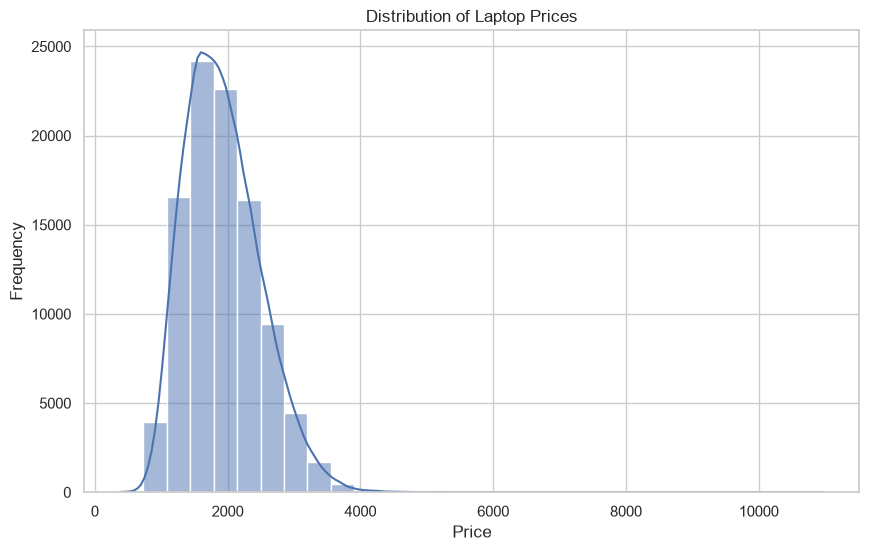

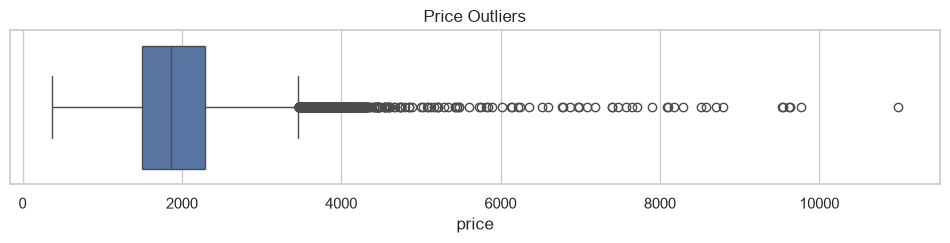

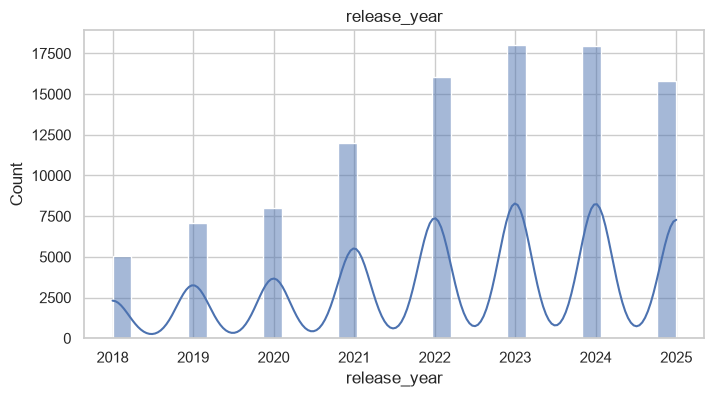

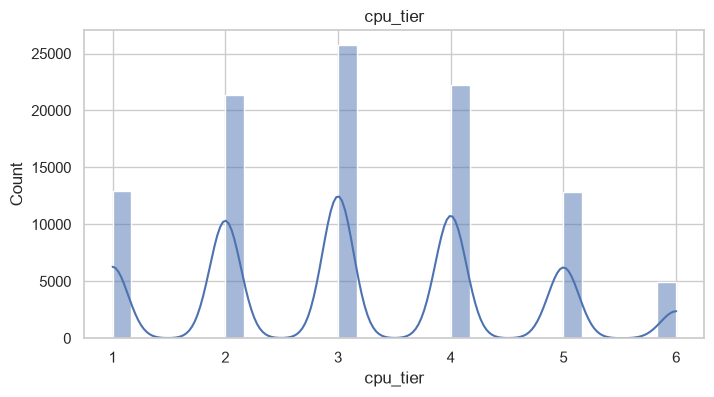

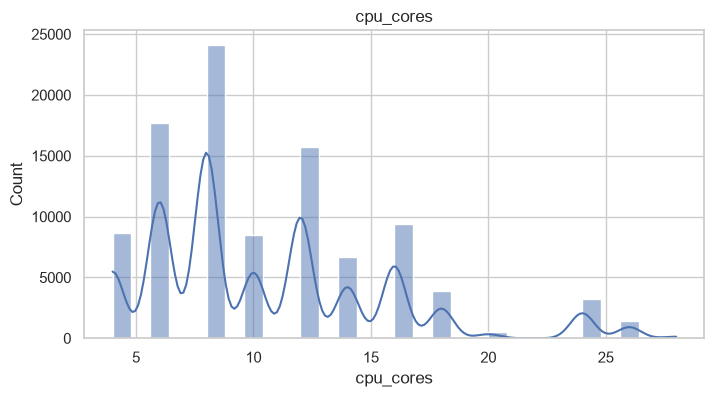

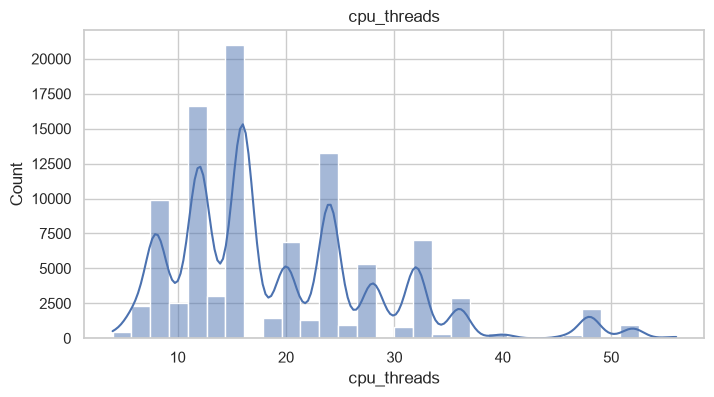

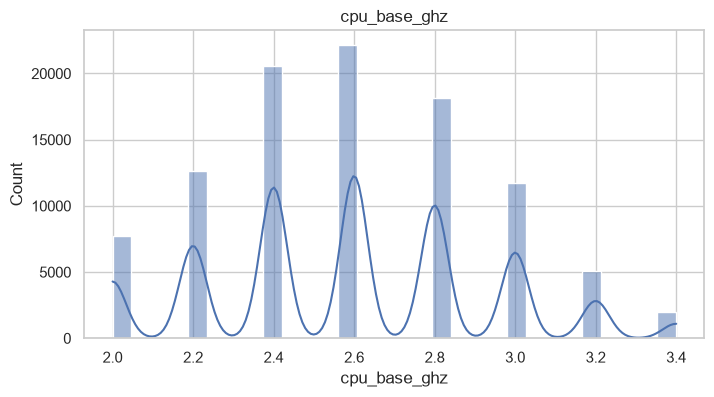

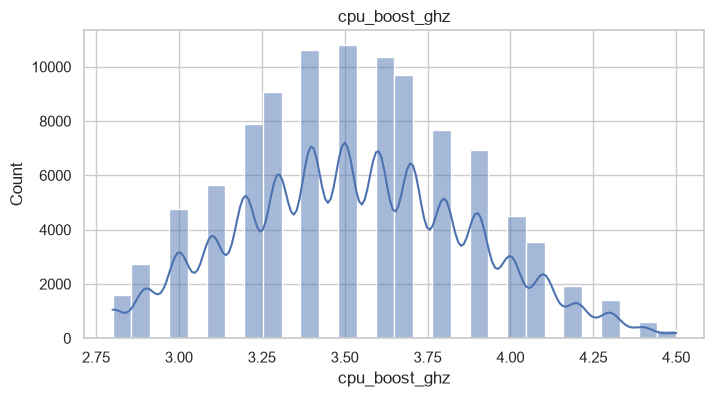

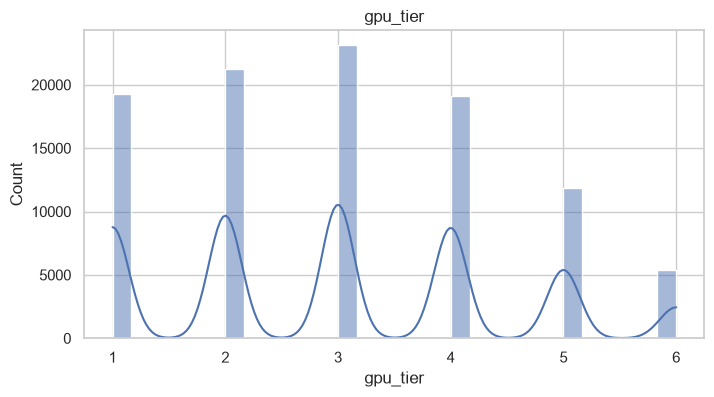

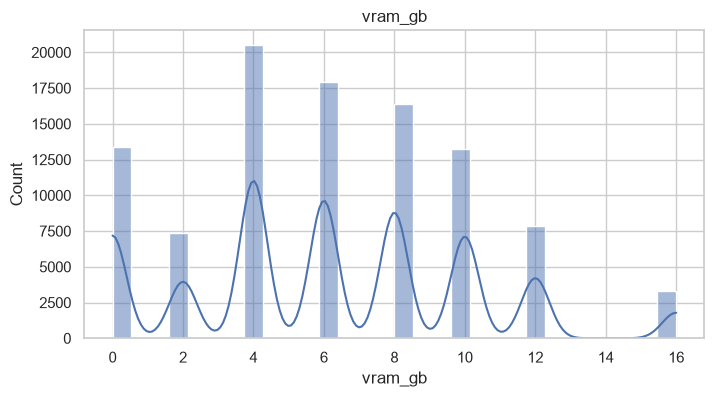

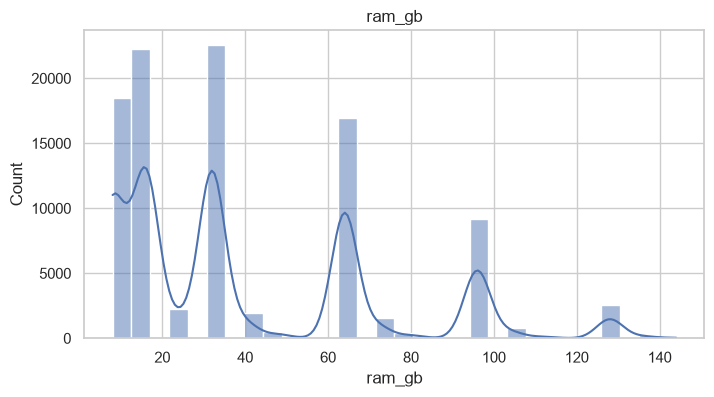

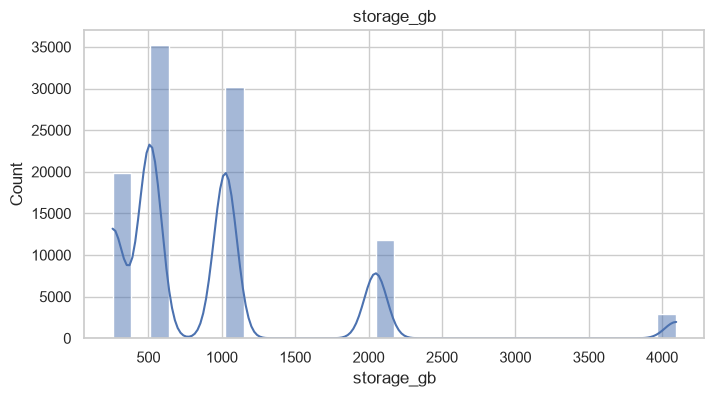

 Skipped 3 categorical columns with >20 unique values: {'gpu_model', 'model', 'cpu_model'}


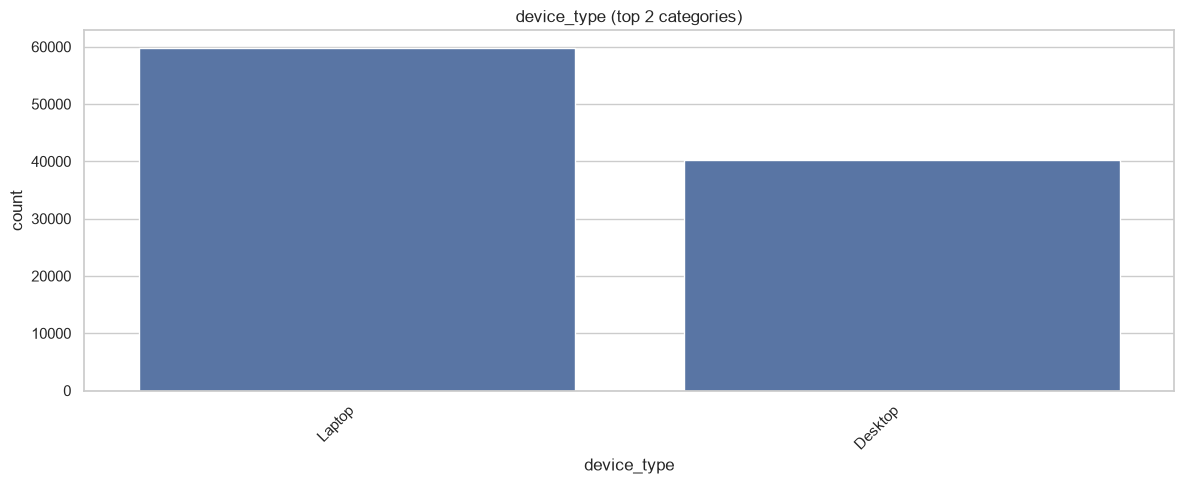

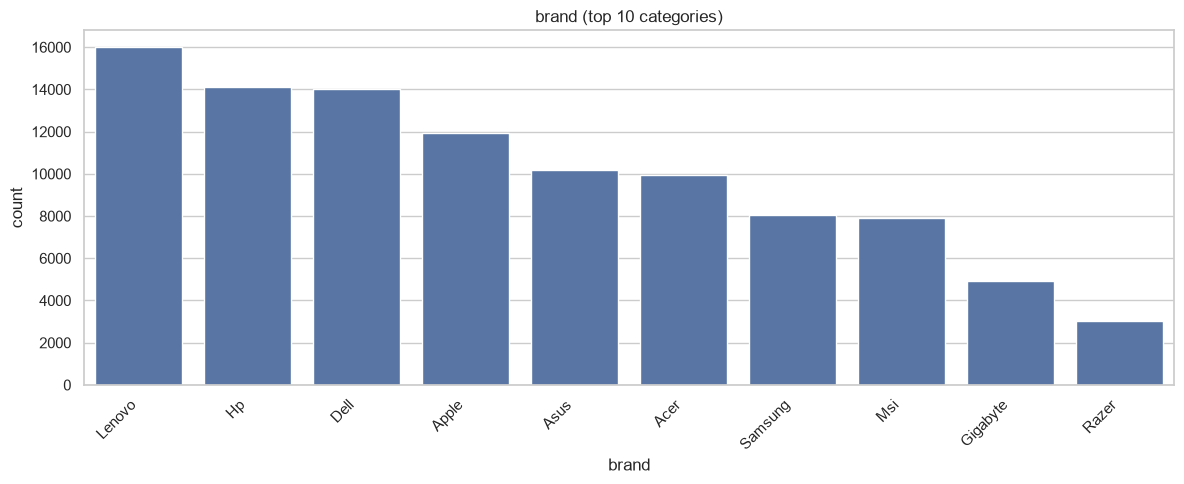

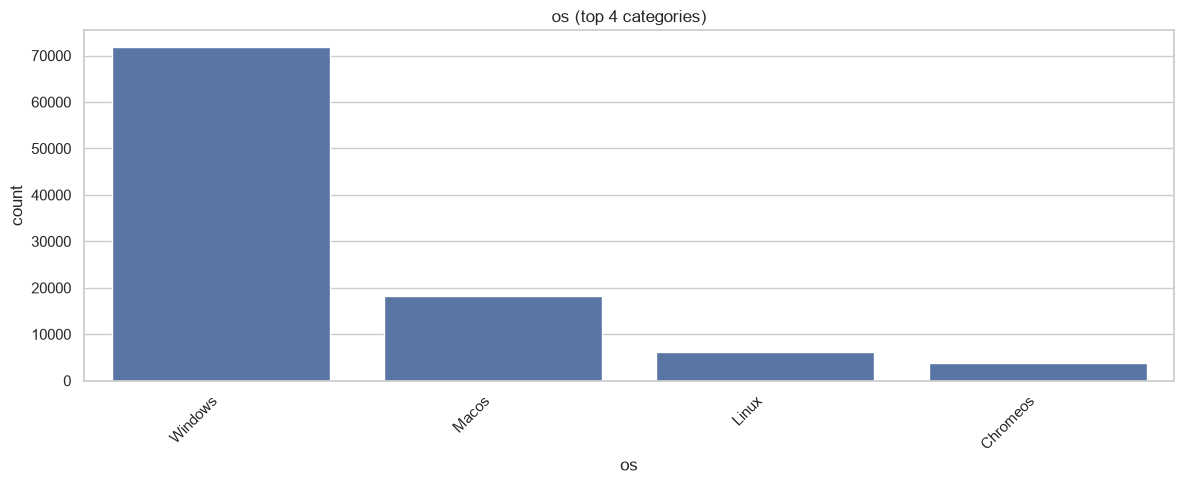

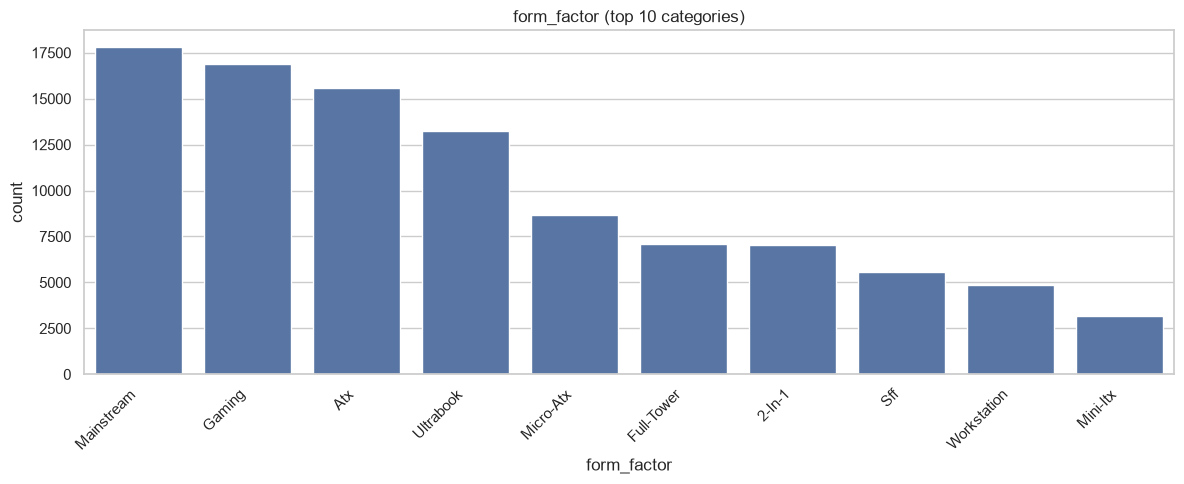

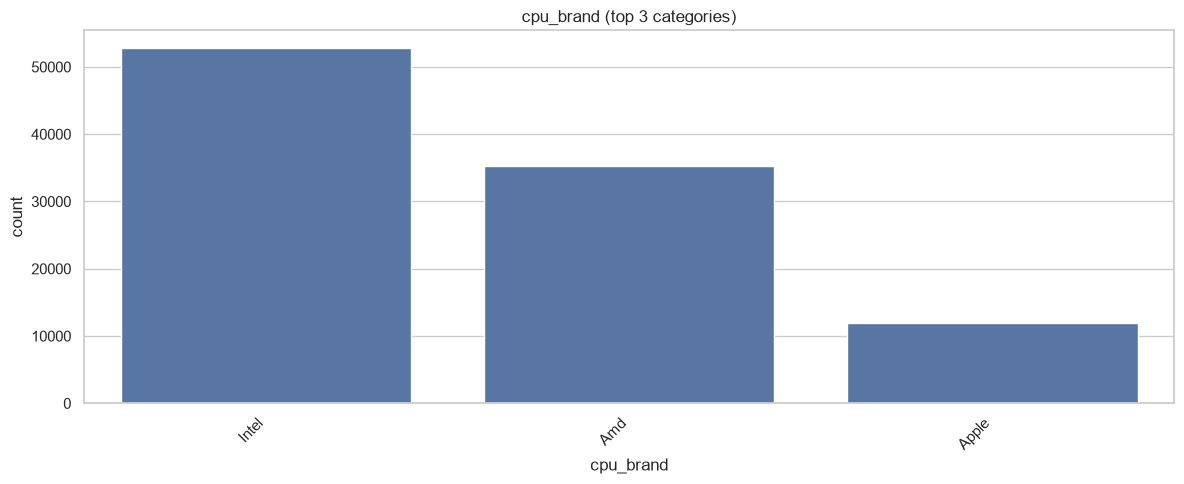

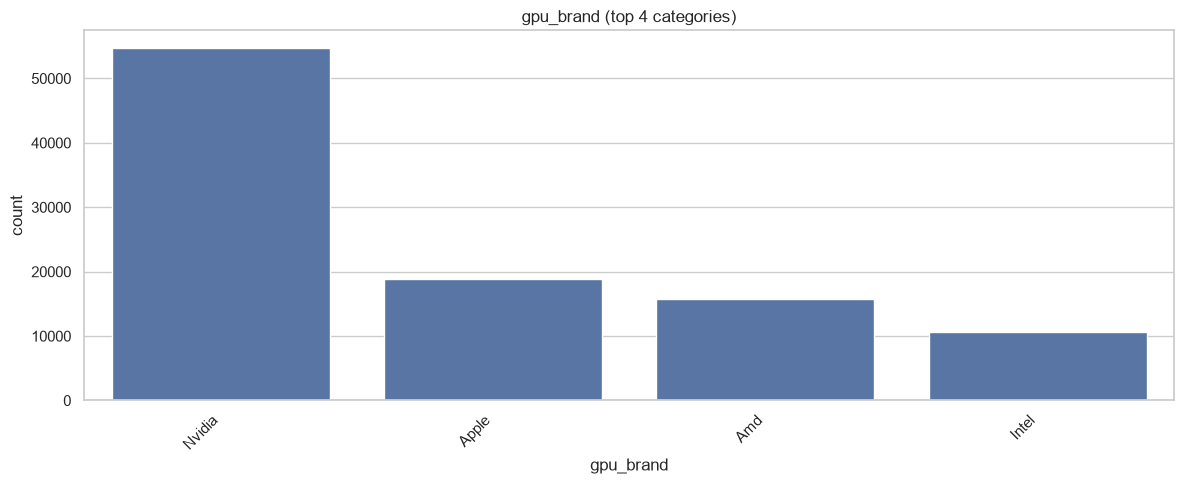

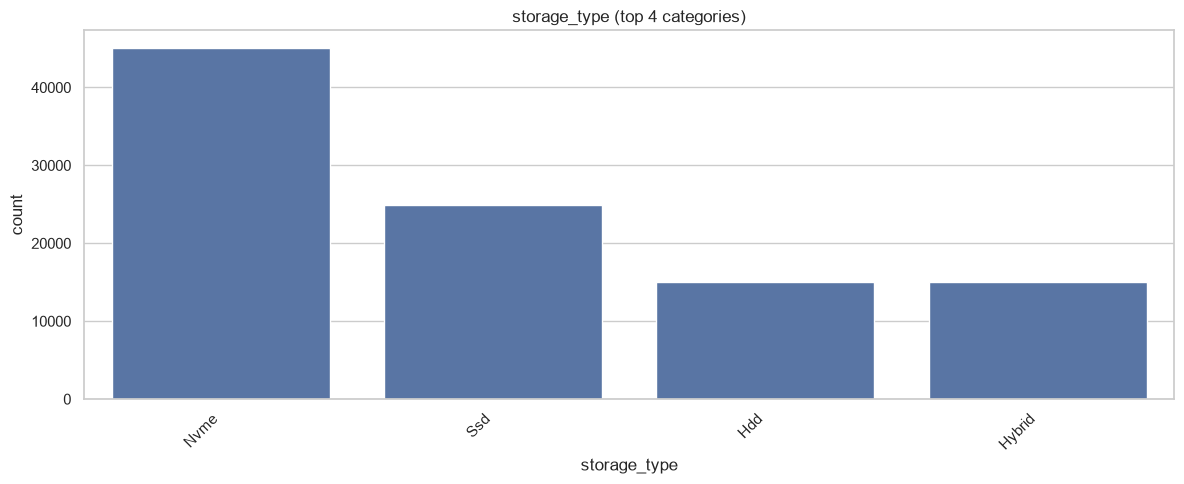

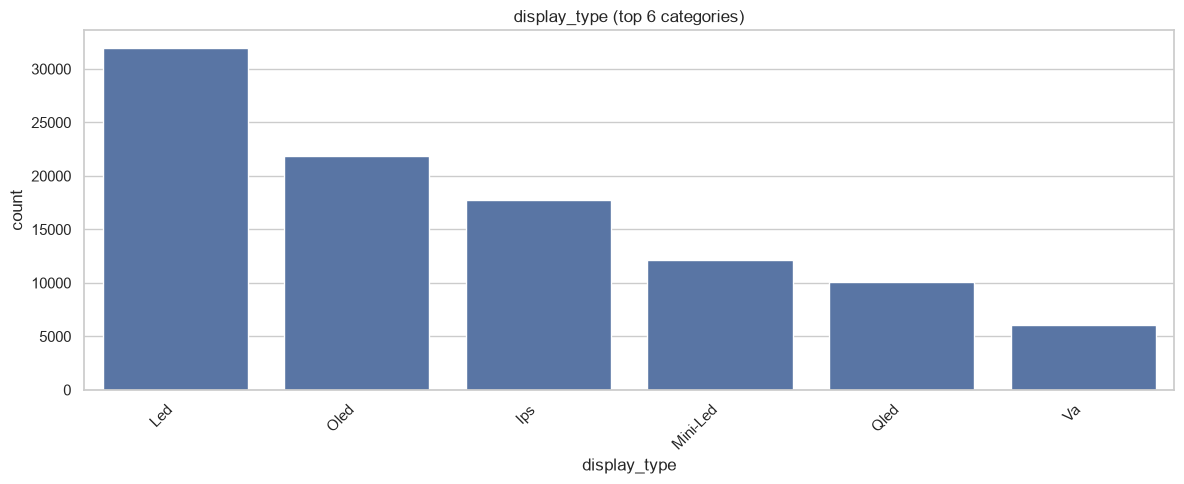

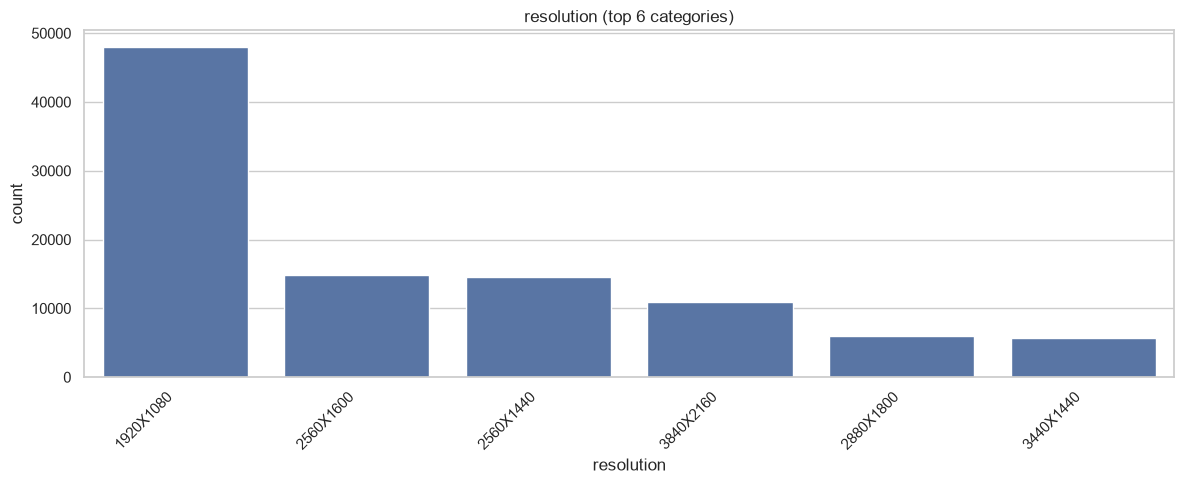

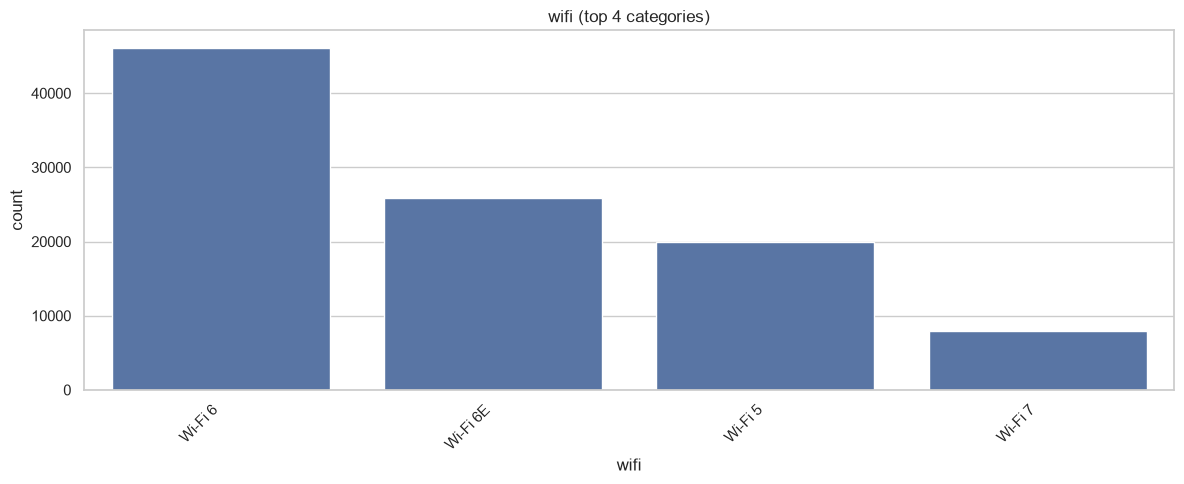

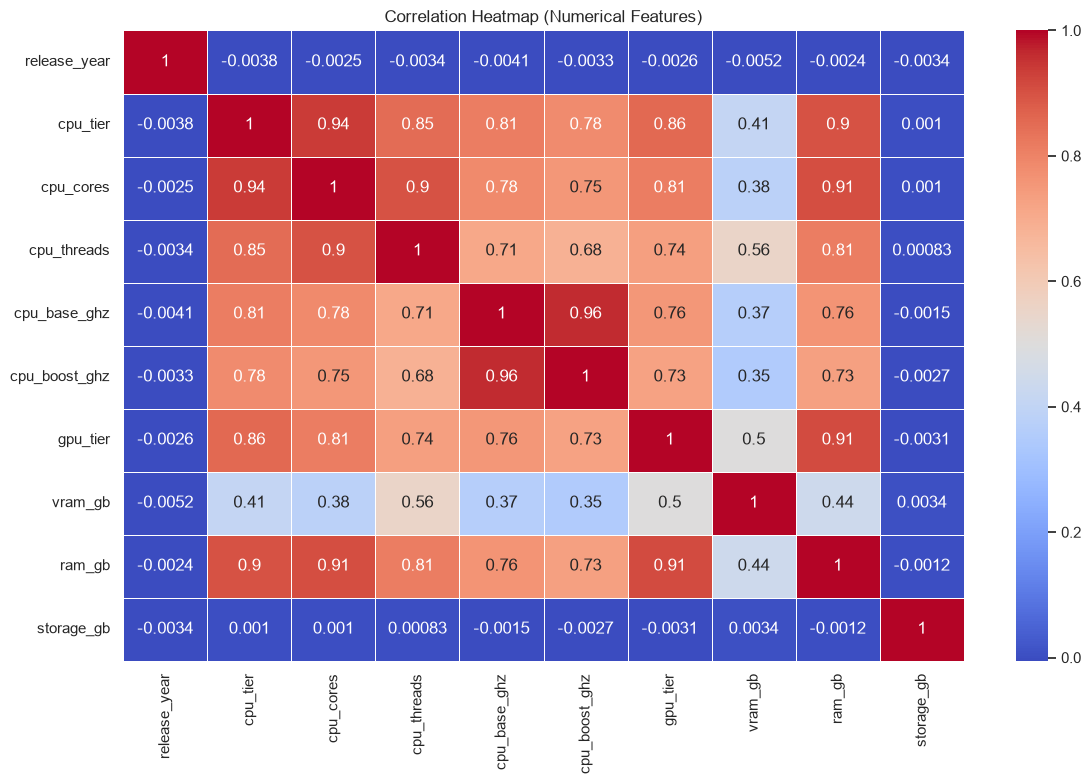

Found 976 outliers in price
    device_type  brand              model  release_year       os  form_factor  \
26       Laptop  Apple      Apple Air W7N          2022    Linux       2-In-1   
149      Laptop  Apple  Apple Stealth Whr          2024  Windows    Ultrabook   
203      Laptop  Apple      Apple Pro Deb          2023  Windows  Workstation   
208      Laptop  Apple    Apple Think 6Z8          2023  Windows       Gaming   
219      Laptop  Apple   Apple Legion Udp          2022  Windows       Gaming   

    cpu_brand     cpu_model  cpu_tier  cpu_cores  cpu_threads  cpu_base_ghz  \
26      Apple  Apple M1 Max         6         26           26           3.0   
149     Apple  Apple M3 Pro         6         24           24           3.0   
203     Apple  Apple M3 Pro         6         24           24           3.0   
208     Apple      Apple M3         5         16           16           2.8   
219     Apple      Apple M2         6         26           26           3.0   

     cpu_b

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# ===== Load data (replace with your centralized paths later) =====
current_eda_dir = Path.cwd()
project_root = current_eda_dir.parent.parent
processed_eda_dir = project_root / "data" / "processed"
processed_eda_dir.mkdir(parents=True, exist_ok=True)
eda_cleaned_csv = processed_eda_dir / "laptop_price_cleaned.csv"
eda_computer_cleaned_csv = processed_eda_dir / "computer_prices_all_cleaned.csv"

df = pd.read_csv(eda_computer_cleaned_csv)
print(df.head())

# Dataset Overview
print("="*60)
print("Dataset Shape:", df.shape)
print("="*60)
print("Columns:", df.columns.tolist())
print("="*60)
print("Data Types:\n", df.dtypes)

# Summary statistics
df.describe(include="all").T

# Target Variable Analysis
fig, ax = plt.subplots(figsize=(10,6))
sns.histplot(data=df, x="price", kde=True, bins=30, ax=ax)
ax.set_title("Distribution of Laptop Prices")
ax.set_xlabel("Price")
ax.set_ylabel("Frequency")
plt.show()
plt.close('all')  # ← ADD THIS: free memory immediately

# Box plot
fig, ax = plt.subplots(figsize=(12,2))
sns.boxplot(x=df["price"], ax=ax)
ax.set_title("Price Outliers")
plt.show()
plt.close('all')  # ← ADD THIS

# ===== FIXED: Limit numerical histograms =====
numerical_columns = df.select_dtypes(include=["int64","float64"]).columns

# ADD THIS: Plot in batches or limit to reasonable number
MAX_PLOTS_PER_TYPE = 10  # safety limit
numerical_columns = numerical_columns[:MAX_PLOTS_PER_TYPE]

for col in numerical_columns:
    fig, ax = plt.subplots(figsize=(8,4))
    sns.histplot(df[col], kde=True, bins=30, ax=ax)
    ax.set_title(col)
    plt.show()
    plt.close('all')  # ← CRITICAL: close after every figure

# ===== FIXED: Skip high-cardinality categorical columns =====
categorical_columns = df.select_dtypes(include=["object", "string"]).columns

# ADD THIS: filter out columns with too many unique values
MAX_CATEGORIES = 20
filtered_cat_cols = [
    col for col in categorical_columns 
    if df[col].nunique() <= MAX_CATEGORIES
]

if len(filtered_cat_cols) < len(categorical_columns):
    skipped = set(categorical_columns) - set(filtered_cat_cols)
    print(f" Skipped {len(skipped)} categorical columns with >{MAX_CATEGORIES} unique values: {skipped}")

for col in filtered_cat_cols:
    fig, ax = plt.subplots(figsize=(12,5))
    # ADD: limit to top N categories if still many
    top_n = df[col].value_counts().nlargest(15).index
    plot_data = df[df[col].isin(top_n)]
    
    sns.countplot(
        data=plot_data,
        x=col,
        order=top_n,
        ax=ax
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_title(f"{col} (top {len(top_n)} categories)")
    plt.tight_layout()  # ← prevent label cutoff
    plt.show()
    plt.close('all')  # ← CRITICAL

# Correlation Heatmap (only on numerical)
corr = df[numerical_columns].corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", linewidths=.5)
plt.title("Correlation Heatmap (Numerical Features)")
plt.tight_layout()
plt.show()
plt.close('all')  # ← ADD THIS

# Outlier detection (unchanged, but add batching if many columns)
def detect_outliers(df, column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    return outliers

price_outliers = detect_outliers(df, "price")
print(f"Found {len(price_outliers)} outliers in price")
print(price_outliers.head())